### Import Libraries

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

import cv2
import torch
import mlflow
import logging
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch import optim
from src.org_unet_parts import *
from dataloader import ACDCDataset
from utils.dice_score import dice_loss
from utils.evaluate import evaluate
%matplotlib inline

INFO:albumentations.check_version:A new version of Albumentations is available: 1.4.21 (you have 1.4.7). Upgrade using: pip install --upgrade albumentations


In [2]:
log_file_name = f'./logs/acdc_original_unet_org_v2{datetime.now().strftime("%Y%m%d%H%M%S")}.log'
logging.basicConfig(filename=log_file_name, level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s', force=True)

In [3]:
torch.cuda.empty_cache()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logging.info(f'Using device {device}')
print(f'Using device {device}')

Using device cuda


In [4]:
mlflow.login() # host: https://community.cloud.databricks.com/
mlflow.set_tracking_uri("databricks")

# Initialize logging - create a new MLflow Experiment
mlflow.set_experiment("/cmri-segmentation-of-ventricular-structures-and-myocardium")

2024/11/07 11:39:42 INFO mlflow.utils.credentials: Successfully connected to MLflow hosted tracking server! Host: https://community.cloud.databricks.com.


<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/1301949192404675', creation_time=1726678925784, experiment_id='1301949192404675', last_update_time=1730959727659, lifecycle_stage='active', name='/cmri-segmentation-of-ventricular-structures-and-myocardium', tags={'mlflow.experiment.sourceName': '/cmri-segmentation-of-ventricular-structures-and-myocardium',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'chinthalanka.23@cse.mrt.ac.lk',
 'mlflow.ownerId': '8299159887893237'}>

In [5]:
dir_checkpoint = Path('./models/checkpoints/original_unet_org_v2/')

epochs = 5
batch_size = 8
lr = 1e-5
scale = 1
amp = False

### Data Loading

In [6]:
root_dir = r'../data/ACDC/img_slices_org_v2/'
logging.info(f'Using root_dir {root_dir}')

training_dataset = ACDCDataset(root_dir=root_dir, dataset='training', transform_ind=True)
validation_dataset = ACDCDataset(root_dir=root_dir, dataset='validation', transform_ind=True)
testing_dataset = ACDCDataset(root_dir=root_dir, dataset='testing', transform_ind=True)

logging.info(f'Training dataset size: {len(training_dataset)}')
logging.info(f'Validation dataset size: {len(validation_dataset)}')
logging.info(f'Testing dataset size: {len(testing_dataset)}')

# Load data from the dataset
train_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=True)

Loaded 2084 training images
Loaded 260 validation images
Loaded 260 testing images


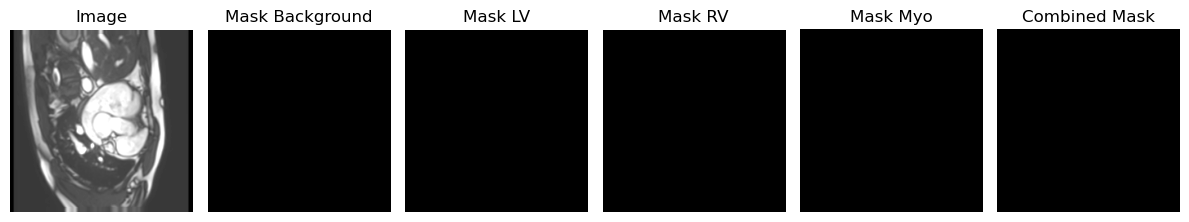

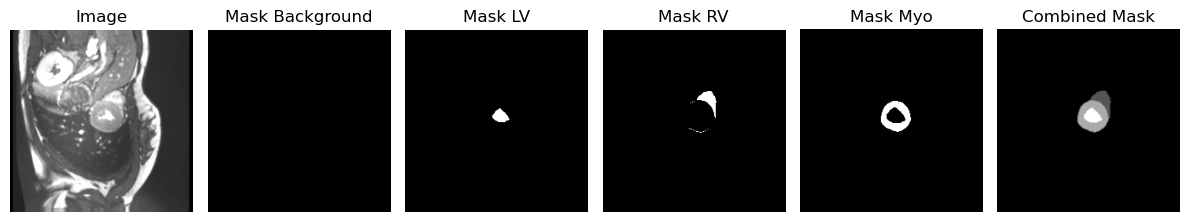

In [7]:
# Iterate through the dataset and plot the first 4 samples
n_samples_to_plot = 2

for i, sample in enumerate(test_dataloader):
    if i >= n_samples_to_plot:
        break
    
    # Extract data from the sample
    image = sample['image'][i].squeeze().numpy()  # Convert to numpy array
    msk_all = sample['masks_all'][i].squeeze().numpy()
    msk_bkg = sample['masks'][i][0].squeeze().numpy()
    msk_lv = sample['masks'][i][1].squeeze().numpy()
    msk_rv = sample['masks'][i][2].squeeze().numpy()
    msk_myo = sample['masks'][i][3].squeeze().numpy()
    
    # Create a figure with subplots
    fig, axes = plt.subplots(1, 6, figsize=(12, 5))
    
    # Plot the image and masks
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Image')
    axes[0].axis('off')
    
    axes[1].imshow(msk_bkg, cmap='gray')
    axes[1].set_title('Mask Background')
    axes[1].axis('off')
    
    axes[2].imshow(msk_lv, cmap='gray')
    axes[2].set_title('Mask LV')
    axes[2].axis('off')
    
    axes[3].imshow(msk_rv, cmap='gray')
    axes[3].set_title('Mask RV')
    axes[3].axis('off')
    
    axes[4].imshow(msk_myo, cmap='gray')
    axes[4].set_title('Mask Myo')
    axes[4].axis('off')
    
    axes[5].imshow(msk_all, cmap='gray')
    axes[5].set_title('Combined Mask')
    axes[5].axis('off')
    
    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

### U-Net Model

In [8]:
class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=False):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = (DoubleConv(n_channels, 64))
        self.down1 = (Down(64, 128))
        self.down2 = (Down(128, 256))
        self.down3 = (Down(256, 512))
        factor = 2 if bilinear else 1
        self.down4 = (Down(512, 1024 // factor))
        self.up1 = (Up(1024, 512 // factor, bilinear))
        self.up2 = (Up(512, 256 // factor, bilinear))
        self.up3 = (Up(256, 128 // factor, bilinear))
        self.up4 = (Up(128, 64, bilinear))
        self.outc = (OutConv(64, n_classes))

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

    def use_checkpointing(self):
        self.inc = torch.utils.checkpoint(self.inc)
        self.down1 = torch.utils.checkpoint(self.down1)
        self.down2 = torch.utils.checkpoint(self.down2)
        self.down3 = torch.utils.checkpoint(self.down3)
        self.down4 = torch.utils.checkpoint(self.down4)
        self.up1 = torch.utils.checkpoint(self.up1)
        self.up2 = torch.utils.checkpoint(self.up2)
        self.up3 = torch.utils.checkpoint(self.up3)
        self.up4 = torch.utils.checkpoint(self.up4)
        self.outc = torch.utils.checkpoint(self.outc)

In [9]:
class UNetV2(nn.Module):
    def __init__(self, n_channels=1, n_classes=3, bilinear=False):
        super(UNetV2, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        # Define the encoder path (contracting path)
        self.encoder = nn.Sequential(
            self.conv_block(n_channels, 64),
            self.conv_block(64, 128),
            self.conv_block(128, 256),
            self.conv_block(256, 512)
        )

        # Define the bottleneck layer
        self.bottleneck = self.conv_block(512, 1024)

        # Define the decoder path (expansive path)
        self.decoder = nn.Sequential(
            self.up_conv_block(1024, 512),
            self.up_conv_block(512, 256),
            self.up_conv_block(256, 128),
            self.up_conv_block(128, 64)
        )

        # Final convolution layer to map to the output masks (LV, RV, MYO)
        self.final_conv = nn.Conv2d(64, n_classes, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def up_conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
            self.conv_block(out_channels, out_channels)
        )

    def forward(self, x):
        # Encoder path
        e1 = self.encoder[0](x)
        e2 = self.encoder[1](e1)
        e3 = self.encoder[2](e2)
        e4 = self.encoder[3](e3)

        # Bottleneck
        b = self.bottleneck(e4)

        # Decoder path with skip connections
        # d = self.decoder[0](b) + e4
        # d = self.decoder[1](d) + e3
        # d = self.decoder[2](d) + e2
        # d = self.decoder[3](d) + e1
        
        # input is CHW
        diffY = e4.size()[2] - b.size()[2]
        diffX = e4.size()[3] - b.size()[3]
        
        b = F.pad(b, [diffX // 2, diffX - diffX // 2,
                      diffY // 2, diffY - diffY // 2])
        
        d = torch.cat([e4, self.decoder[0](b)], dim=1)
        d = torch.cat([e3, self.decoder[1](d)], dim=1)
        d = torch.cat([e2, self.decoder[2](d)], dim=1)
        d = torch.cat([e1, self.decoder[3](d)], dim=1)

        # Final layer
        out = self.final_conv(d)
        return out
    
    def use_checkpointing(self):
        self.encoder[0] = torch.utils.checkpoint(self.encoder[0])
        self.encoder[1] = torch.utils.checkpoint(self.encoder[1])
        self.encoder[2] = torch.utils.checkpoint(self.encoder[2])
        self.encoder[3] = torch.utils.checkpoint(self.encoder[3])
        self.bottleneck = torch.utils.checkpoint(self.bottleneck)
        self.decoder[0] = torch.utils.checkpoint(self.decoder[0])
        self.decoder[1] = torch.utils.checkpoint(self.decoder[1])
        self.decoder[2] = torch.utils.checkpoint(self.decoder[2])
        self.decoder[3] = torch.utils.checkpoint(self.decoder[3])
        self.final_conv = torch.utils.checkpoint(self.final_conv)


### Model Training

In [10]:
def train_model(
        model,
        device,
        epochs: int = 5,
        batch_size: int = 1,
        learning_rate: float = 1e-5,
        save_checkpoint: bool = True,
        img_scale: float = 0.5,
        amp: bool = False,
        weight_decay: float = 1e-8,
        momentum: float = 0.999,
        gradient_clipping: float = 1.0,
):
    n_train = len(training_dataset)
    n_val = len(validation_dataset)
    
    # Start an MLflow run
    with mlflow.start_run():
        logging.info(f'''Starting training:
            Epochs:          {epochs}
            Batch size:      {batch_size}
            Learning rate:   {learning_rate}
            Training size:   {n_train}
            Validation size: {n_val}
            Checkpoints:     {save_checkpoint}
            Device:          {device.type}
            Images scaling:  {img_scale}
            Mixed Precision: {amp}
        ''')
        
        params = {
            'epochs': epochs,
            'batch_size': batch_size,
            'learning_rate': learning_rate,
            'training_set_size': n_train,
            'validation_set_size': n_val,
            'img_scale': img_scale,
            'mixed_precision': amp
        }
        
        mlflow.log_params(params)

        # Set up the optimizer, the loss, the learning rate scheduler and the loss scaling for AMP
        # optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum, foreach=True)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay, foreach=True)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5)  # goal: maximize Dice score
        grad_scaler = torch.cuda.amp.GradScaler(enabled=amp)
        # criterion = nn.BCELoss() if model.n_classes > 1 else nn.BCEWithLogitsLoss() # nn.CrossEntropyLoss()
        criterion = nn.BCEWithLogitsLoss()
        global_step = 0

        # Begin training
        for epoch in range(1, epochs + 1):
            model.train()
            epoch_loss = 0
            with tqdm(total=n_train, desc=f'Epoch {epoch}/{epochs}', unit='img') as pbar:
                for batch in train_dataloader:
                    # images, msks_lv, msks_rv, msks_myo = batch['image'], batch['mask_lv'], batch['mask_rv'], batch['mask_myo']
                    images, masks, masks_all = batch['image'], batch['masks'], batch['masks_all']
                    images = images.permute(0, 3, 1, 2)
                    # masks_all = torch.argmax(masks_all, dim=1)
                    masks_all = masks_all.permute(0, 3, 1, 2)
                    # logging.info(f"images shape: {images.shape}")
                    # logging.info(f"true masks shape: {masks.shape}")
    
                    assert images.shape[1] == model.n_channels, \
                        f'Network has been defined with {model.n_channels} input channels, ' \
                        f'but loaded images have {images.shape[1]} channels. Please check that ' \
                        'the images are loaded correctly.'
    
                    images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                    true_masks = masks.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                    # true_masks = masks_all.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
    
                    with torch.autocast(device.type if device.type != 'mps' else 'cpu', enabled=amp):
                        # masks_pred = model(images).permute(1, 0, 2, 3)
                        masks_pred = model(images)
                        # logging.info(f"masks pred shape: {masks_pred.shape}")
                        if model.n_classes == 1:
                            loss_ce = criterion(masks_pred.squeeze(1), true_masks.float())
                            loss_dice = dice_loss(F.sigmoid(masks_pred.squeeze(1)), true_masks.float(), multiclass=False)
                            loss = 0.4 * loss_ce + 0.6 * loss_dice
                        else:
                            loss_ce = criterion(masks_pred, true_masks)  # true_masks.squeeze(1).long()
                            loss_dice = dice_loss(
                                # masks_pred,
                                # true_masks,
                                F.softmax(masks_pred, dim=1).float(),
                                # F.sigmoid(masks_pred > 0.5).float(),
                                true_masks.float(),
                                # F.softmax(masks_pred, dim=1).float(),
                                # F.one_hot(true_masks, model.n_classes).permute(0, 3, 1, 2).float(),
                                multiclass=True
                            )
                            loss = 0.4 * loss_ce + 0.6 * loss_dice
    
                    optimizer.zero_grad(set_to_none=True)
                    grad_scaler.scale(loss).backward()
                    grad_scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clipping)
                    grad_scaler.step(optimizer)
                    grad_scaler.update()
    
                    pbar.update(images.shape[0])
                    global_step += 1
                    epoch_loss += loss.item()
                    pbar.set_postfix(**{'loss (batch)': loss.item()})
    
                    # Evaluation round
                    division_step = (n_train // (5 * batch_size))
                    if division_step > 0:
                        if global_step % division_step == 0:
                            val_score = evaluate(model, val_dataloader, device, amp)
                            scheduler.step(val_score)
                            logging.info('Validation Dice score: {}'.format(val_score))
    
            if save_checkpoint:
                Path(dir_checkpoint).mkdir(parents=True, exist_ok=True)
                state_dict = model.state_dict()
                # state_dict['mask_values'] = training_dataset.mask_values
                torch.save(state_dict, str(dir_checkpoint / 'checkpoint_epoch{}.pth'.format(epoch)))
                logging.info(f'Checkpoint {epoch} saved!')
        
        # Log train, validation and test set Dice Scores
        train_dice_score = evaluate(model, train_dataloader, device, amp)
        val_dice_score = evaluate(model, val_dataloader, device, amp)
        test_dice_score = evaluate(model, test_dataloader, device, amp)
        
        mlflow.log_metric("train_dice_score", train_dice_score)
        mlflow.log_metric("val_dice_score", val_dice_score)
        mlflow.log_metric("test_dice_score", test_dice_score)
        
        logging.info('Overall Train Set Dice score: {}'.format(train_dice_score))
        logging.info('Overall Validation Set Dice score: {}'.format(val_dice_score))
        logging.info('Overall Test Dice Set score: {}'.format(test_dice_score))

### Training

In [11]:
# n_channels=3 for RGB images
# n_classes is the number of probabilities you want to get per pixel
model = UNet(n_channels=1, n_classes=4, bilinear=False)
# model = UNetV2(n_channels=1, n_classes=3)
model = model.to(memory_format=torch.channels_last)

logging.info(f'Network:\n'
                 f'\t{model.n_channels} input channels\n'
                 f'\t{model.n_classes} output channels (classes)\n'
                 f'\t{"Bilinear" if model.bilinear else "Transposed conv"} upscaling')

model.to(device=device)

try:
    train_model(
        model=model,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=lr,
        device=device,
        img_scale=scale,
        amp=amp
    )
except torch.cuda.OutOfMemoryError:
    logging.error('Detected OutOfMemoryError! '
                  'Enabling checkpointing to reduce memory usage, but this slows down training. '
                  'Consider enabling AMP (--amp) for fast and memory efficient training')
    torch.cuda.empty_cache()
    model.use_checkpointing()
    train_model(
        model=model,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=lr,
        device=device,
        img_scale=scale,
        amp=amp
    )

Epoch 5/5: 100%|██████████| 2084/2084 [10:42<00:00,  3.24img/s, loss (batch)=0.749]


### Testing and Evaluation

In [30]:
def visualize_prediction(model, dataloader, device, sample_idx=0, img_idx=0, n_classes=4, combined_mask=True):
    plt.style.use("classic")
    model.eval()
    with torch.no_grad():
        for i, sample in enumerate(dataloader):
            if i == sample_idx:
                # Extract data from the sample
                images = sample['image']
                true_masks = sample['masks']
                true_masks_all = sample['masks_all']
                print(f'images shape: {images.shape}')
                print(f'true masks shape: {true_masks.shape}')
                print(f'combined true masks shape: {true_masks_all.shape}')
                images = images.permute(0, 3, 1, 2)
                true_masks_all = true_masks_all.permute(0, 3, 1, 2)
                
                images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                # true_masks = true_masks.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                # true_masks_all = true_masks_all.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                # true_masks = (true_masks * 255).round().long()
                true_masks_all = (true_masks_all * 255).round().long()

                outputs = model(images)

                # Apply sigmoid to convert logits to probabilities, then threshold
                # preds = torch.sigmoid(outputs)
                preds = (outputs > 0.5).float()  # Convert to binary masks (0 or 1)
                # preds = preds.float().cpu().numpy().squeeze(1)
                
                # Convert logits to predicted class labels
                # preds = torch.argmax(outputs, dim=1).long()
                
                image = images[img_idx].cpu().squeeze()
                true_mask_all = true_masks_all[img_idx].cpu().squeeze().numpy()
                true_mask_bkg = true_masks[img_idx][0].cpu().squeeze().numpy()
                true_mask_lv = true_masks[img_idx][1].cpu().squeeze().numpy()
                true_mask_rv = true_masks[img_idx][2].cpu().squeeze().numpy()
                true_mask_myo = true_masks[img_idx][3].cpu().squeeze().numpy()
                
                # Apply argmax to get the class with the highest probability for each pixel
                pred_mask_all = None
                # pred_mask_all = torch.argmax(preds[img_idx], dim=0).cpu().numpy()  # Shape: (height, width)
                # pred_mask_all = preds[img_idx].cpu().numpy()
                
                print(f'preds shape: {preds.shape}')
                print(f'True mask unique values: {np.unique(true_mask_all)}')
                # print(f'Pred mask unique values: {np.unique(pred_mask_all)}')
                
                if n_classes > 1 and combined_mask:
                    fig, ax = plt.subplots(1, 6, figsize=(16, 5), facecolor='white')
                    ax[0].imshow(image, cmap='gray')
                    ax[0].set_title('Input Image')
    
                    ax[1].imshow(true_mask_lv, cmap='gray')
                    ax[1].set_title('True LV')
    
                    ax[2].imshow(true_mask_rv, cmap='gray')
                    ax[2].set_title('True RV')
    
                    ax[3].imshow(true_mask_myo, cmap='gray')
                    ax[3].set_title('True MYO')
                    
                    ax[4].imshow(true_mask_all, cmap='viridis')
                    ax[4].set_title('True Mask')
                    
                    ax[5].imshow(pred_mask_all, cmap='viridis')
                    ax[5].set_title('Predicted Mask')
                elif n_classes > 1 and not combined_mask:
                    fig, ax = plt.subplots(2, 5, figsize=(20, 8), facecolor='white')
                    ax[0][0].imshow(image, cmap='gray')
                    ax[0][0].set_title('Input Image')
                    
                    ax[0][1].imshow(true_mask_bkg, cmap='gray')
                    ax[0][1].set_title('True Background')
    
                    ax[0][2].imshow(true_mask_lv, cmap='gray')
                    ax[0][2].set_title('True LV')
    
                    ax[0][3].imshow(true_mask_rv, cmap='gray')
                    ax[0][3].set_title('True RV')
    
                    ax[0][4].imshow(true_mask_myo, cmap='gray')
                    ax[0][4].set_title('True MYO')
    
                    ax[1][0].imshow(image, cmap='gray')
                    ax[1][0].set_title('Input Image')
                    
                    ax[1][1].imshow(preds[img_idx][0].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][1].set_title('Pred Background')
    
                    ax[1][2].imshow(preds[img_idx][1].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][2].set_title('Pred LV')
    
                    ax[1][3].imshow(preds[img_idx][2].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][3].set_title('Pred RV')
    
                    ax[1][4].imshow(preds[img_idx][3].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][4].set_title('Pred MYO')
                else:
                    print(f'Image: {torch.unique(images[img_idx])}')
                    print(f'True Mask: {torch.unique(true_masks_all[img_idx])}')
                    print(f'Pred Mask: {np.unique(preds[img_idx])}')
                    
                    fig, ax = plt.subplots(2, 2, figsize=(8, 8), facecolor='white')
                    ax[0][0].imshow(image, cmap='gray')
                    ax[0][0].set_title('Input Image')
                    
                    ax[0][1].imshow(true_mask_all, cmap='gray')
                    ax[0][1].set_title('True Mask')
                    
                    ax[1][0].imshow(image, cmap='gray')
                    ax[1][0].set_title('Input Image')
                    
                    ax[1][1].imshow(pred_mask_all, cmap='gray')
                    ax[1][1].set_title('Predicted Mask')

                plt.show()
                break  # Visualize only one image
            else:
                continue

images shape: torch.Size([8, 224, 224, 1])
true masks shape: torch.Size([8, 4, 224, 224])
combined true masks shape: torch.Size([8, 224, 224, 1])
preds shape: torch.Size([8, 4, 224, 224])
True mask unique values: [  0  21  42  64  85 105 128 149 170 192 213 234 255]


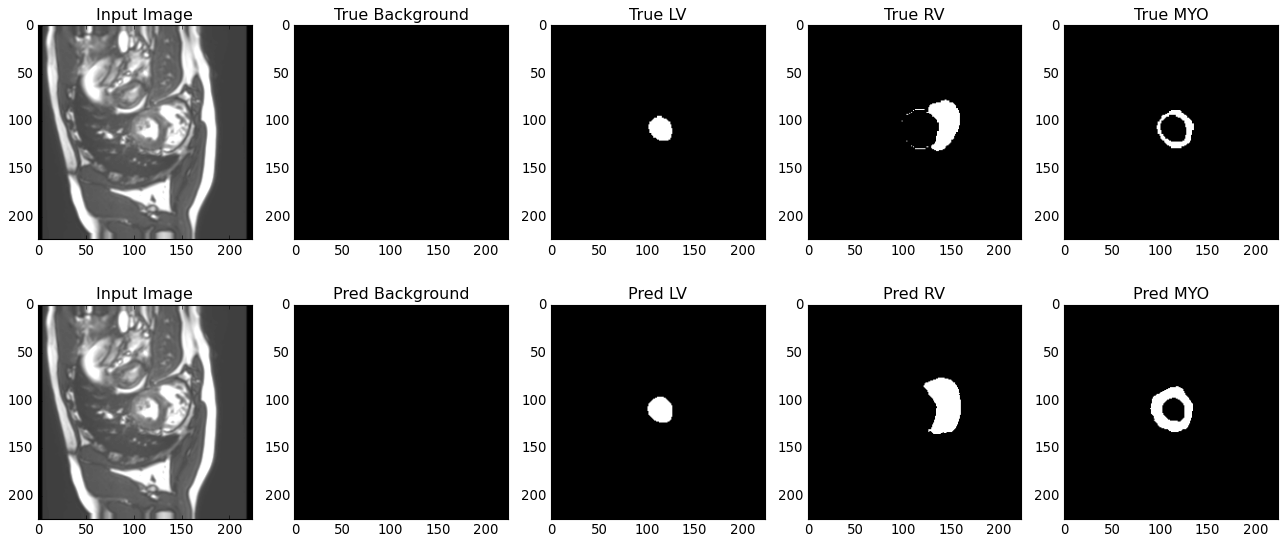

In [32]:
visualize_prediction(model, test_dataloader, device, sample_idx=1, img_idx = 6, n_classes=4, combined_mask=False)

In [ ]:
# torch.cuda.empty_cache()